# Challenge Participant Workflow

This notebook demonstrates the workflow for a **BioDCASE 2026 Active Learning Challenge** participant.

We will:
1. Initialise an `ActiveLearner` with the ESC10 demo dataset
2. Run an active learning loop using **random sampling** (the challenge baseline)
3. Track the **running AULC** (Area Under the Learning Curve) at each cycle
4. Export a JSON result file containing the AULC and full training history

---

**AULC** is computed as the area under the curve of mAP (macro) vs number of labelled training samples,
using the trapezoidal rule, normalised by the x-axis range so the result lies in **[0, 1]**:

$$\text{AULC} = \frac{\int_{n_0}^{n_\text{max}} \text{mAP}(n)\, dn}{n_\text{max} - n_0}$$

A higher AULC means better mAP is achieved with fewer labels — this is the primary ranking metric
for the BioDCASE 2026 challenge.

In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path().absolute().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

from core.active_learner import ActiveLearner

c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
core.active_learner - INFO - Pre-warming UMAP (triggering numba JIT compilation)...
core.active_learner - INFO - UMAP pre-warming completed in 6.7923583984375


In [2]:
# ---------------------------------------------------------------------------
# Submission configuration — edit these before running
# ---------------------------------------------------------------------------
AUTHOR_LASTNAME        = "smith"          # used in the output filename
INSTITUTE_ABBREVIATION = "MIT"            # used in the output filename

# AL loop parameters
N_CYCLES            = 5
EPOCHS_PER_CYCLE    = 15
BATCH_SIZE          = 8

# Warm-up: number of high-density samples to pre-label before the AL loop.
# Set to None to skip warm-up (cold start).
PRETRAIN_SAMPLES: int | None = 20

# Batch size scheduler: list of samples to select per AL cycle.
# - If None, N_SAMPLES_PER_CYCLE is used for every cycle.
# - If a list shorter than N_CYCLES, the last value is repeated.
# - MAX_BUDGET still applies on top of the schedule (warm-up counts toward it).
# Examples:
#   None                     → [10, 10, 10, 10, 10]  (fixed)
#   [32, 32, 16, 8, 8]       → warm start then fine-grained
#   [10, 20, 30, 40, 50]     → increasing budget per cycle
N_SAMPLES_PER_CYCLE = 10          # used when BATCH_SCHEDULE is None
BATCH_SCHEDULE = None             # or e.g. [32, 32, 16, 8, 8]

# Optional: stop once this many samples have been labelled (None = no cap).
# Warm-up samples count toward this budget.
MAX_BUDGET: int | None = None

# ---------------------------------------------------------------------------
# Derived schedule (do not edit)
# ---------------------------------------------------------------------------
def _resolve_schedule(schedule, n_cycles, default):
    if schedule is None:
        return [default] * n_cycles
    padded = list(schedule)
    while len(padded) < n_cycles:
        padded.append(padded[-1])
    return padded[:n_cycles]

_schedule = _resolve_schedule(BATCH_SCHEDULE, N_CYCLES, N_SAMPLES_PER_CYCLE)
print(f"Warm-up samples : {PRETRAIN_SAMPLES or 0}")
print(f"Batch schedule  : {_schedule}")

Warm-up samples : 20
Batch schedule  : [10, 10, 10, 10, 10]


## Step 1: Initialise the ActiveLearner

Point the learner at the ESC10 demo dataset embeddings and labels.
We use `sampling_strategy="random"` — the challenge baseline.

In [3]:
EMBEDDINGS_DIR = PROJECT_ROOT / "ESC10_BASEAL" / "embeddings" / "birdnet"
LABELS_PATH    = PROJECT_ROOT / "ESC10_BASEAL" / "labels.csv"

learner = ActiveLearner(
    embeddings_dir=EMBEDDINGS_DIR,
    annotations_path=LABELS_PATH,
    model_name="birdnet",
    dataset_name="ESC10",
    learning_rate=0.001,
    sampling_strategy="random",   # baseline strategy
    device="cpu",
    verbose=False,
    pretrain_samples=PRETRAIN_SAMPLES,
)

state = learner.get_state()
print(f"Total samples : {state['n_labeled'] + state['n_unlabeled']}")
print(f"Labelled      : {state['n_labeled']}  (includes {learner.pretrain_samples} warm-up)")
print(f"Unlabelled    : {state['n_unlabeled']}")
print(f"Classes       : {state['num_classes']}")

Total samples : 800
Labelled      : 20  (includes 20 warm-up)
Unlabelled    : 780
Classes       : 10


## Step 2: Run the active learning loop

Each cycle:
- Selects `n_samples_per_cycle` samples via the configured strategy
- Adds them to the labelled pool
- Trains the model and records metrics (including running AULC)

In [4]:
print(f"{'Cycle':>5}  {'Scheduled':>9}  {'Labelled':>8}  {'mAP':>6}  {'AULC (running)':>16}")
print("-" * 55)

for cycle in range(N_CYCLES):
    scheduled = _schedule[cycle]

    # Respect optional budget cap
    if MAX_BUDGET is not None:
        remaining = MAX_BUDGET - len(learner.labeled_indices)
        if remaining <= 0:
            print(f"Budget of {MAX_BUDGET} samples reached — stopping early.")
            break
        n_to_sample = min(scheduled, remaining)
    else:
        n_to_sample = scheduled

    selected = learner.sample(n_samples=n_to_sample)
    learner.add_samples(selected)
    metrics = learner.train_step(epochs=EPOCHS_PER_CYCLE, batch_size=BATCH_SIZE)

    print(f"{cycle+1:>5}  {n_to_sample:>9}  {metrics['n_labeled']:>8}  {metrics['mAP']:>6.4f}  {metrics['aulc_mAP']:>16.4f}")

Cycle  Scheduled  Labelled     mAP    AULC (running)
-------------------------------------------------------


c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\core\active_learner.py:685: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  batch = torch.from_numpy(self.embeddings[start:start + bs]).to(self.device)


    1         10        30  0.6372            0.0000
    2         10        40  0.6913            0.6643
    3         10        50  0.8335            0.7133
    4         10        60  0.8871            0.7623
    5         10        70  0.9130            0.7968


## Step 3: Visualise the learning curve and AULC

The shaded area under the mAP curve is the AULC.

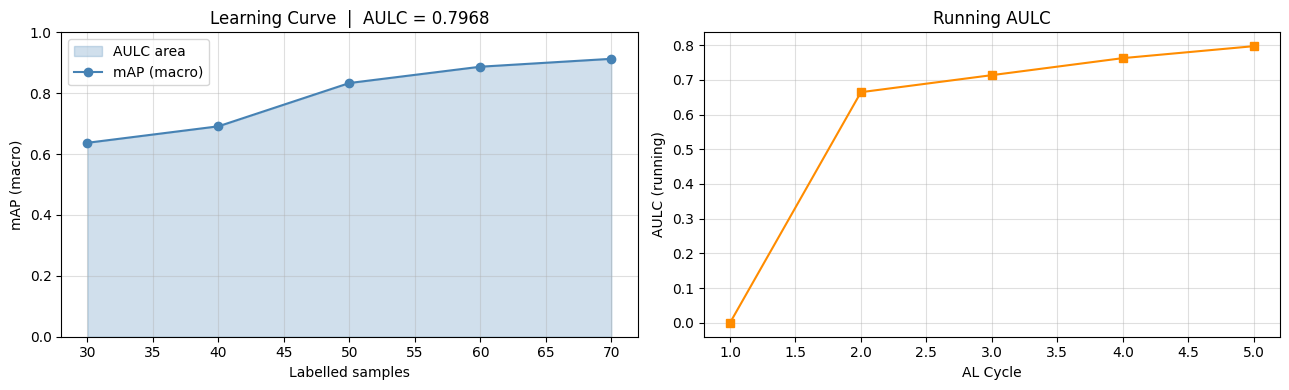


Final AULC: 0.7968


In [5]:
history    = learner.training_history
n_labeled  = [h['n_labeled']  for h in history]
mAPs       = [h['mAP']        for h in history]
aulc_curve = [h['aulc_mAP']   for h in history]
final_aulc = learner.compute_aulc('mAP')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: mAP learning curve with shaded AULC ---
axes[0].fill_between(n_labeled, mAPs, alpha=0.25, color='steelblue', label='AULC area')
axes[0].plot(n_labeled, mAPs, marker='o', color='steelblue', label='mAP (macro)')
axes[0].set_xlabel('Labelled samples')
axes[0].set_ylabel('mAP (macro)')
axes[0].set_title(f'Learning Curve  |  AULC = {final_aulc:.4f}')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# --- Right: running AULC over cycles ---
cycles = list(range(1, len(aulc_curve) + 1))
axes[1].plot(cycles, aulc_curve, marker='s', color='darkorange')
axes[1].set_xlabel('AL Cycle')
axes[1].set_ylabel('AULC (running)')
axes[1].set_title('Running AULC')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
print(f"\nFinal AULC: {final_aulc:.4f}")

## Step 4: Export results to YAML

This is the file you would include in your submission `.zip`. It contains:
- `config` — hyperparameters and model size (for reproducibility)
- `learning_curve` — per-cycle `n_labeled`, `mAP`, `accuracy`, `f1_score`, and running AULC values
- `supplementary` — sampling wall-time, annotation cost, and computational cost (training)

In [6]:
OUTPUT_DIR = PROJECT_ROOT / "results" / "challenge_submissions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Filename: {method}_{dataset}_{lastname}.yaml
strategy_name = learner.sampling_strategy.method
output_file   = OUTPUT_DIR / f"{strategy_name}_{learner.dataset_name}_{AUTHOR_LASTNAME}.yaml"

learner.export(
    str(output_file),
    author_lastname=AUTHOR_LASTNAME,
    institute_abbreviation=INSTITUTE_ABBREVIATION,
    max_budget=MAX_BUDGET,
)

print(f"Saved to: {output_file}")
print()
hist = learner.training_history
print(f"Summary")
print(f"  Sampling strategy : {strategy_name}")
print(f"  Cycles            : {len(hist)}")
print(f"  Final labelled    : {hist[-1]['n_labeled']}")
print(f"  Final mAP         : {hist[-1]['mAP']:.4f}")
print(f"  AULC (mAP)        : {hist[-1]['aulc_mAP']:.4f}")
print(f"  AULC (Accuracy)   : {hist[-1]['aulc_accuracy']:.4f}")
print(f"  AULC (F1)         : {hist[-1]['aulc_f1_score']:.4f}")
print(f"  Total sampling t  : {sum(e.get('sampling_time_s', 0) for e in hist):.3f}s")
print(f"  Total annot. cost : {sum(e.get('annotation_cost', 0) for e in hist)}")

Saved to: c:\Users\bjmcewen\OneDrive - Tilburg University\Documents\GitHub\BaseAL\results\challenge_submissions\random_ESC10_smith.yaml

Summary
  Sampling strategy : random
  Cycles            : 5
  Final labelled    : 70
  Final mAP         : 0.9130
  AULC (mAP)        : 0.7968
  AULC (Accuracy)   : 0.6755
  AULC (F1)         : 0.6337
  Total sampling t  : 0.001s
  Total annot. cost : 50


## Next steps

To beat the baseline, try replacing `sampling_strategy="random"` with one of:

| Strategy | Description |
|---|---|
| `"margin"` | Selects samples the model is least confident about |
| `"coreset_farthest"` | Selects samples that are most diverse in feature space |
| `"nn_disagreement"` | Selects samples where nearest neighbours disagree |
| `"custom"` | Implement your own strategy in `core/utils/sampling.py` |

A higher AULC means your strategy reaches better mAP with fewer labels — the goal of active learning.